In [1]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

In [2]:
dataset, info = tfds.load('horses_or_humans', with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/horses_or_humans/incomplete.A8EUFJ_3.0.0/horses_or_humans-train.tfrecord*.…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/horses_or_humans/incomplete.A8EUFJ_3.0.0/horses_or_humans-test.tfrecord*..…

Dataset horses_or_humans downloaded and prepared to /root/tensorflow_datasets/horses_or_humans/3.0.0. Subsequent calls will reuse this data.


In [3]:
train_data, validation_data = dataset['train'], dataset['test']

In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, (150, 150)) # Whenever an image is passed, it needs to be 150 X 150 as to keep the size of image consistent
    image = image/255.0 # convert pixels between 0 to 1
    return image, label

In [5]:
train_data = train_data.map(preprocess).batch(32).shuffle(1000) # 32 batch means we can process batches in parallel
validation_data = validation_data.map(preprocess).batch(32)

In [6]:
# Just to display what is there in the data.
def display_sample(dataset, class_names, num_samples=5):
    plt.figure(figsize=(12, 6)) # 12 inches width, 6 inches height
    count = 0
    for image, labels in dataset.take(1):
      for i in range(num_samples*2):
        ax = plt.subplot(2, num_samples, i+1)
        plt.imshow(image[i].numpy())
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis('off')
        plt.title(class_names[labels[i]])
        count += 1
        if count == num_samples * 2:
          break

class_names = ['Horse', 'Human']

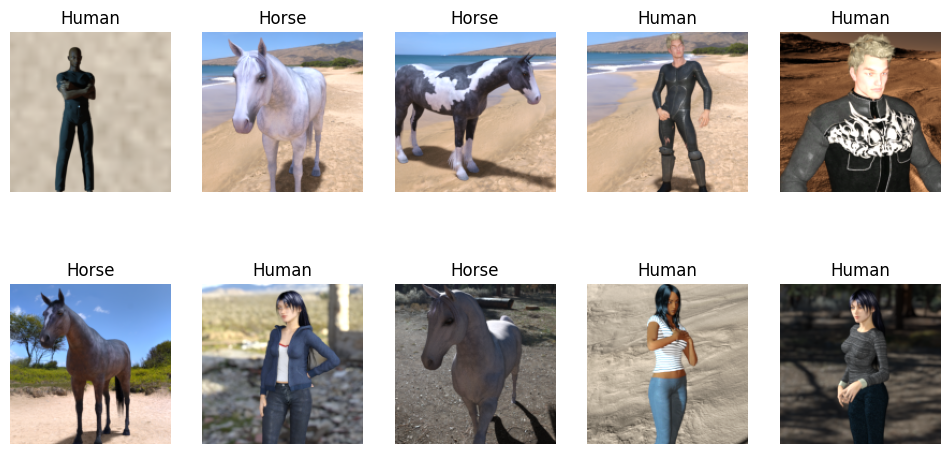

In [7]:
display_sample(train_data, class_names)

In [8]:
# Build Convolution Neural Network
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(2, 2))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten()) # After extracting features, it will build the feature columns.
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Means in the image it will navigate from .... feet forogh network (It will take the image and apply all neural network and identify the image
          # and if that prediction is wrong then new weights are assigned to all the neurons. So Dropout=0.5 means keep the weight for
          # 50% of the neurons same as before and only update the weight of 50%)
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dropout is a neural network regularization technique that prevents overfitting by randomly deactivating (or "dropping") a percentage of neurons during each training iteration. This forces the network to learn more robust and redundant features, as it cannot rely on any single neuron being present, leading to better generalization on unseen data.  

In [9]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history = model.fit(train_data, epochs=10, validation_data=validation_data)

Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.6549 - loss: 0.8173 - val_accuracy: 0.7539 - val_loss: 1.5986
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9706 - loss: 0.0996 - val_accuracy: 0.8164 - val_loss: 1.5256
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9800 - loss: 0.0520 - val_accuracy: 0.8281 - val_loss: 1.7424
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9961 - loss: 0.0144 - val_accuracy: 0.8164 - val_loss: 2.3759
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9893 - loss: 0.0237 - val_accuracy: 0.8203 - val_loss: 1.8709
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9950 - loss: 0.0193 - val_accuracy: 0.8477 - val_loss: 1.3055
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9950 - loss: 0.0118 - val_accuracy: 0.8438 - val_loss: 2.5246
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9947 - loss: 0.0189 - val_accuracy: 0.8203 -

In [11]:
model.save('horse_human_cnn.h5')

In [13]:
history.history['accuracy'] # Shows accuracy in each Epoch (ITERATION)

[0.781889021396637,
 0.9659201502799988,
 0.9834469556808472,
 0.9961051344871521,
 0.992210328578949,
 0.9902629256248474,
 0.9970788955688477,
 0.9980525970458984,
 0.9990262985229492,
 0.98052579164505]

In [14]:
def preprocess_single_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(150, 150))
    img = tf.keras.utils.img_to_array(img)
    img = img/255.0
    img_array = np.expand_dims(img, axis=0)
    return img_array

In [33]:
sample_image = '/content/human4.jpg'

In [34]:
preprocessed_image = preprocess_single_image(sample_image)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


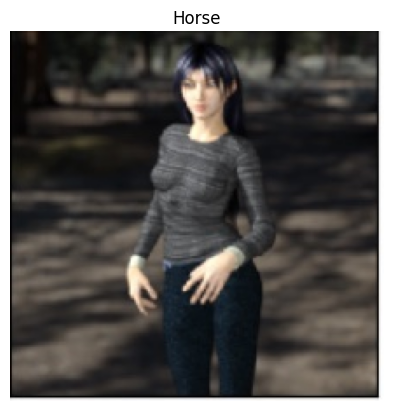

In [35]:
prediction = model.predict(preprocessed_image)
plt.imshow(tf.keras.utils.load_img(sample_image))
plt.axis('off')
plt.title(class_names[int(prediction[0][0])])
plt.show()